# 02 — Exploratory Time-Series Analysis

Six figures, each answering one business question. All computed on data **before the test window** — exploring the holdout is a soft leak.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()))
warnings.filterwarnings('ignore')

from src.config import load_config
from src.data.loader import load_panel
cfg = load_config()
panel = load_panel(cfg)
print(f'panel: {len(panel):,} rows, {panel.series_id.nunique()} series, {panel.date.nunique()} days')

panel: 1,003,600 rows, 600 series, 1969 days


In [2]:
from src import eda
findings = eda.run(cfg)

rows (pre-test)          : 986,800
series / days            : 600 / 1,941
zero share               : 58.95%
mean demand              : 1.619 units/series/day
weekday peak             : Sun (max/min ratio 1.50)
SNAP lift                : +10.2%
top 20% series demand    : 73.4%
median selling-day share : 0.38
growth first->last 8w    : +38.1%
demand by price band     : {'<-15%': 5.9, '-15..-5%': 5.11, '±5%': 3.69, '+5..15%': 5.65, '>+15%': 3.43}

[figures] /projects/sandbox/aiml-portfolio/aiml4-demand-forecasting/reports/figures


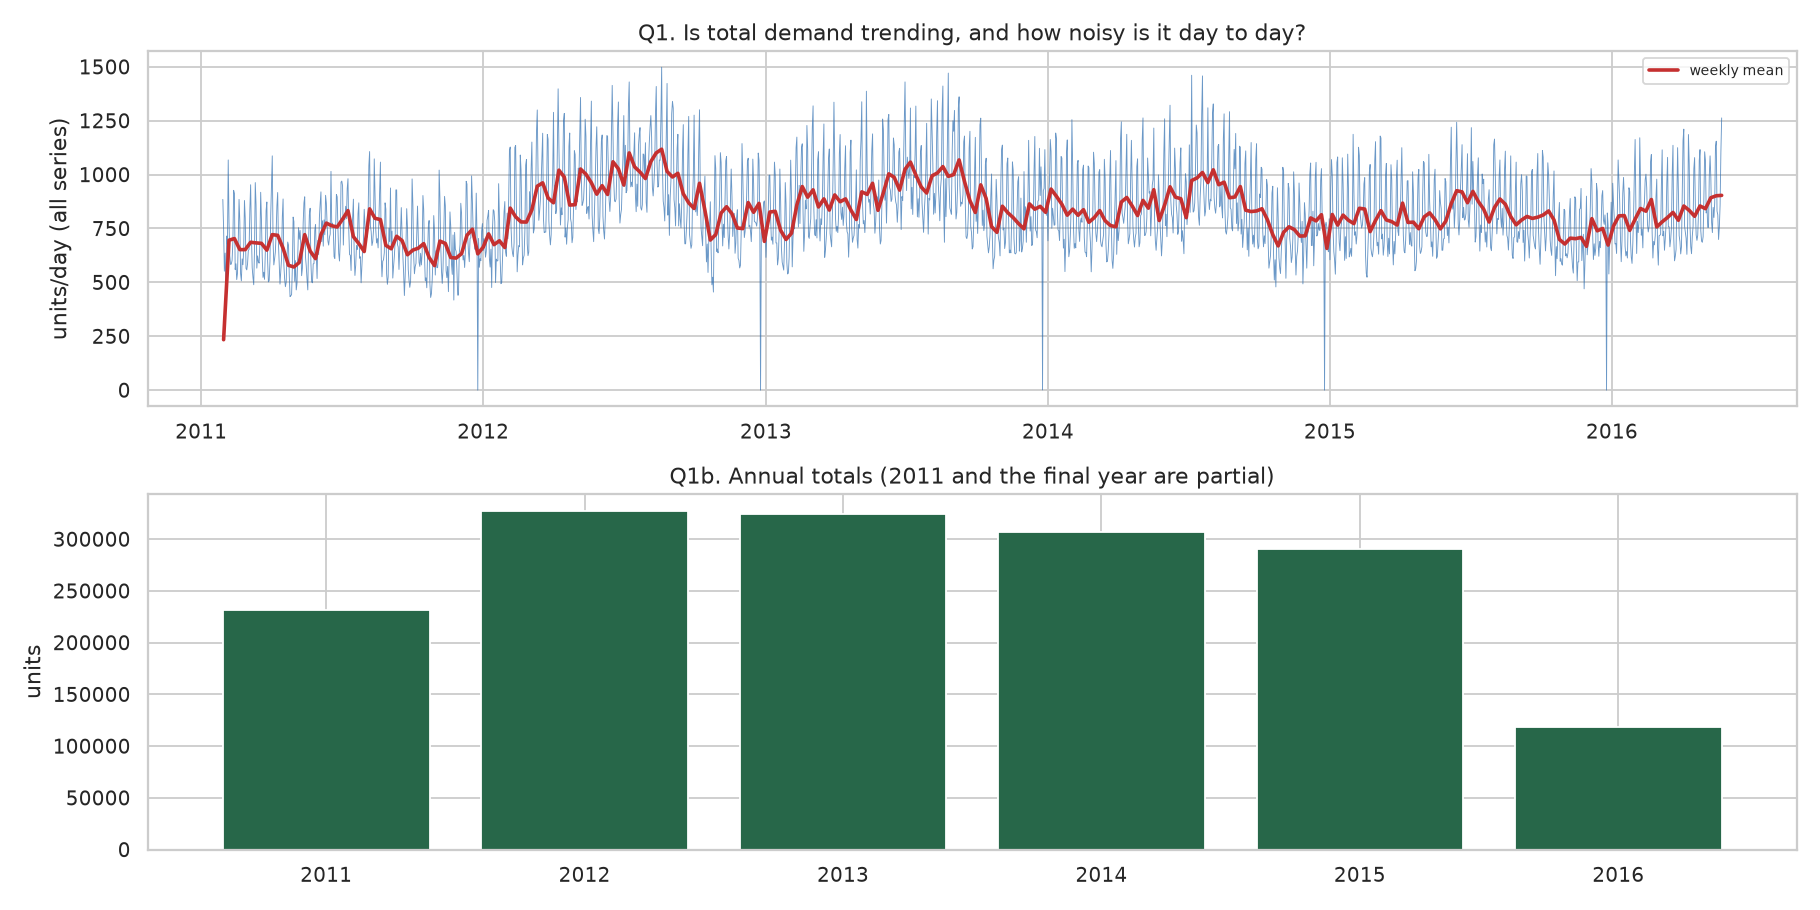

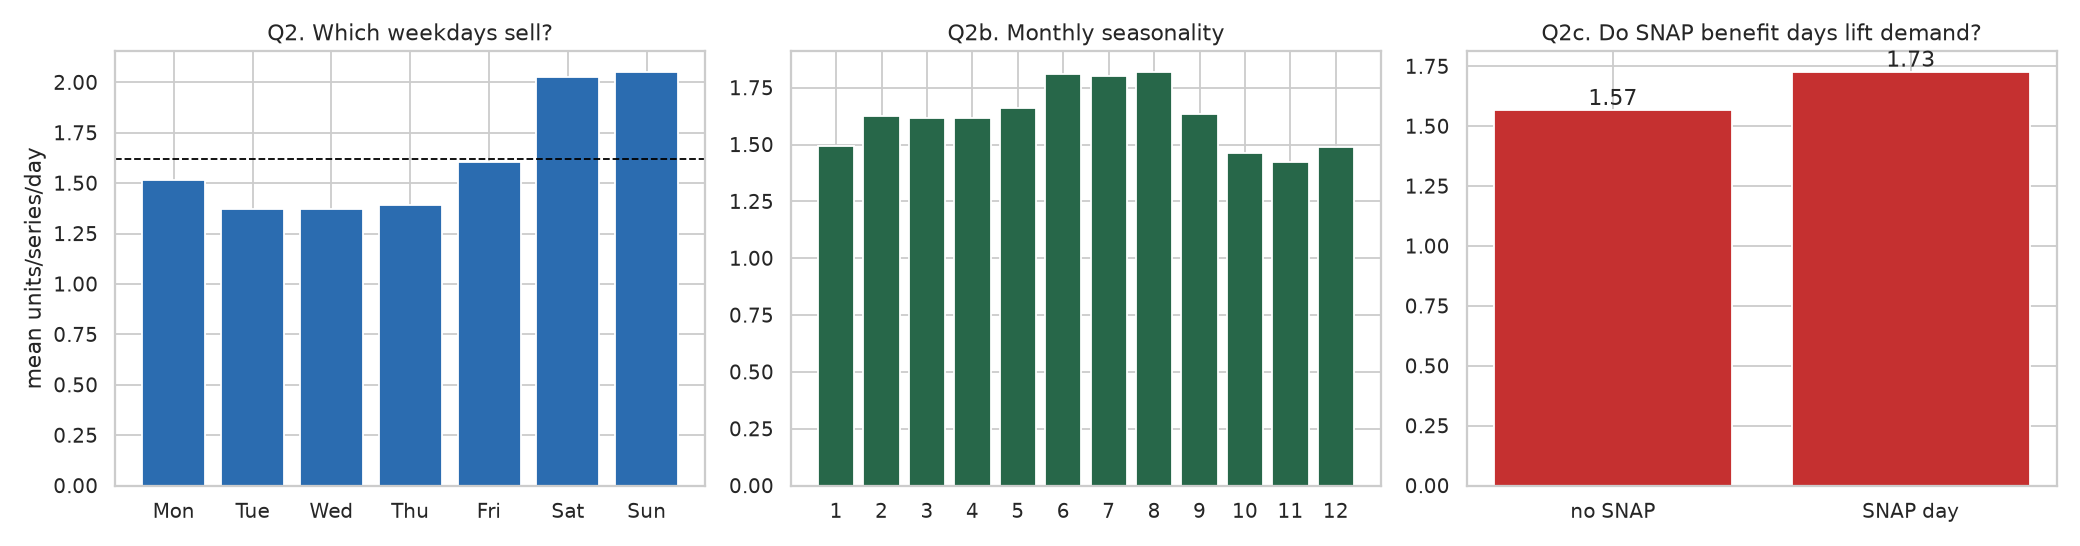

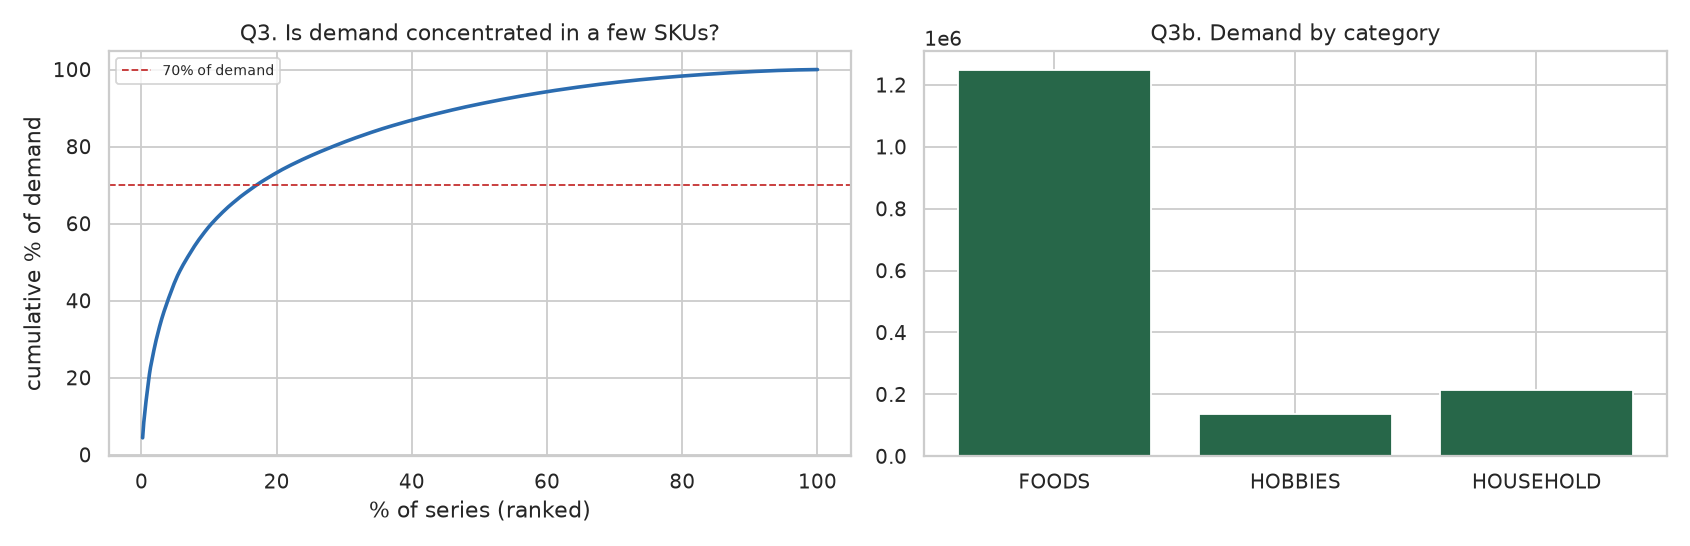

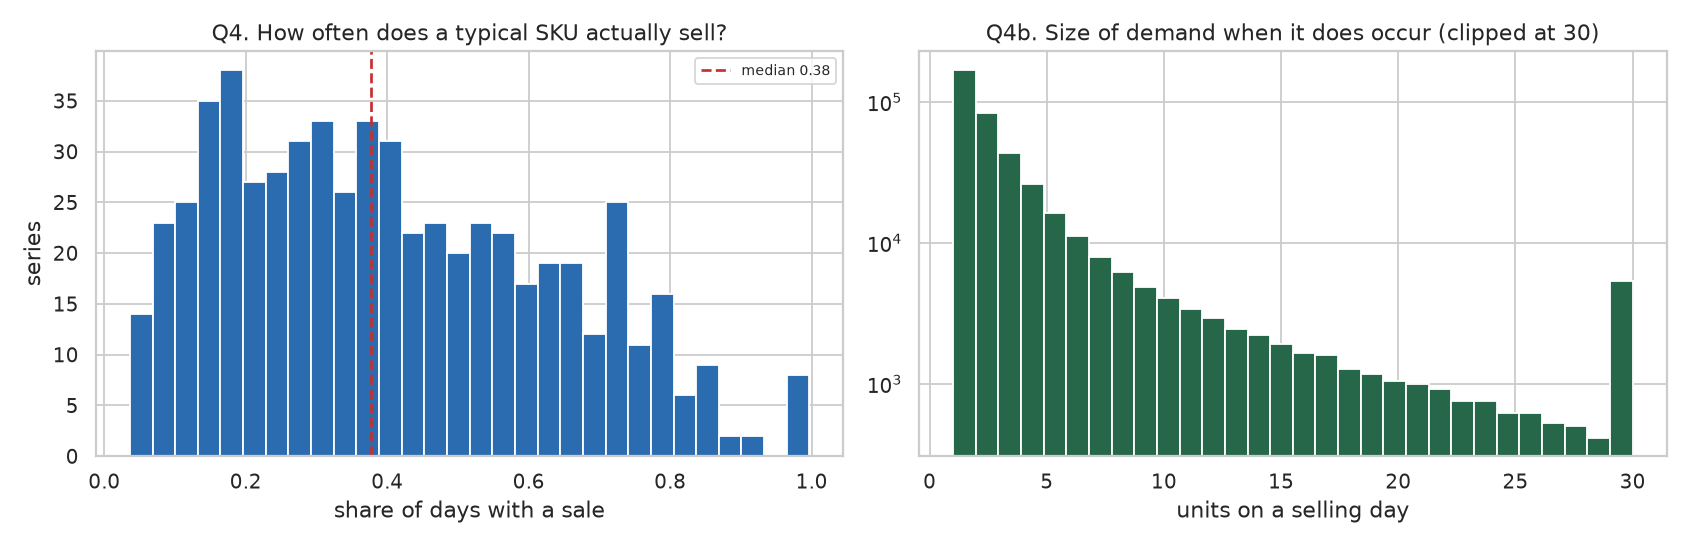

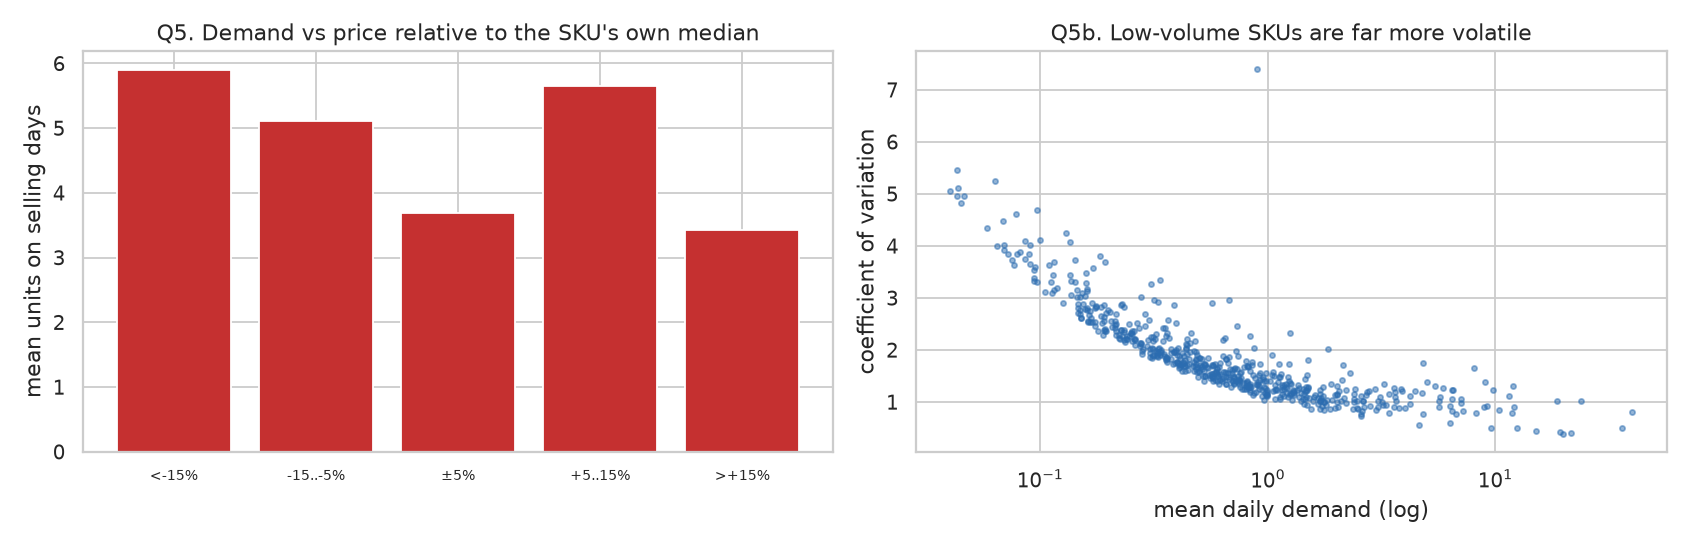

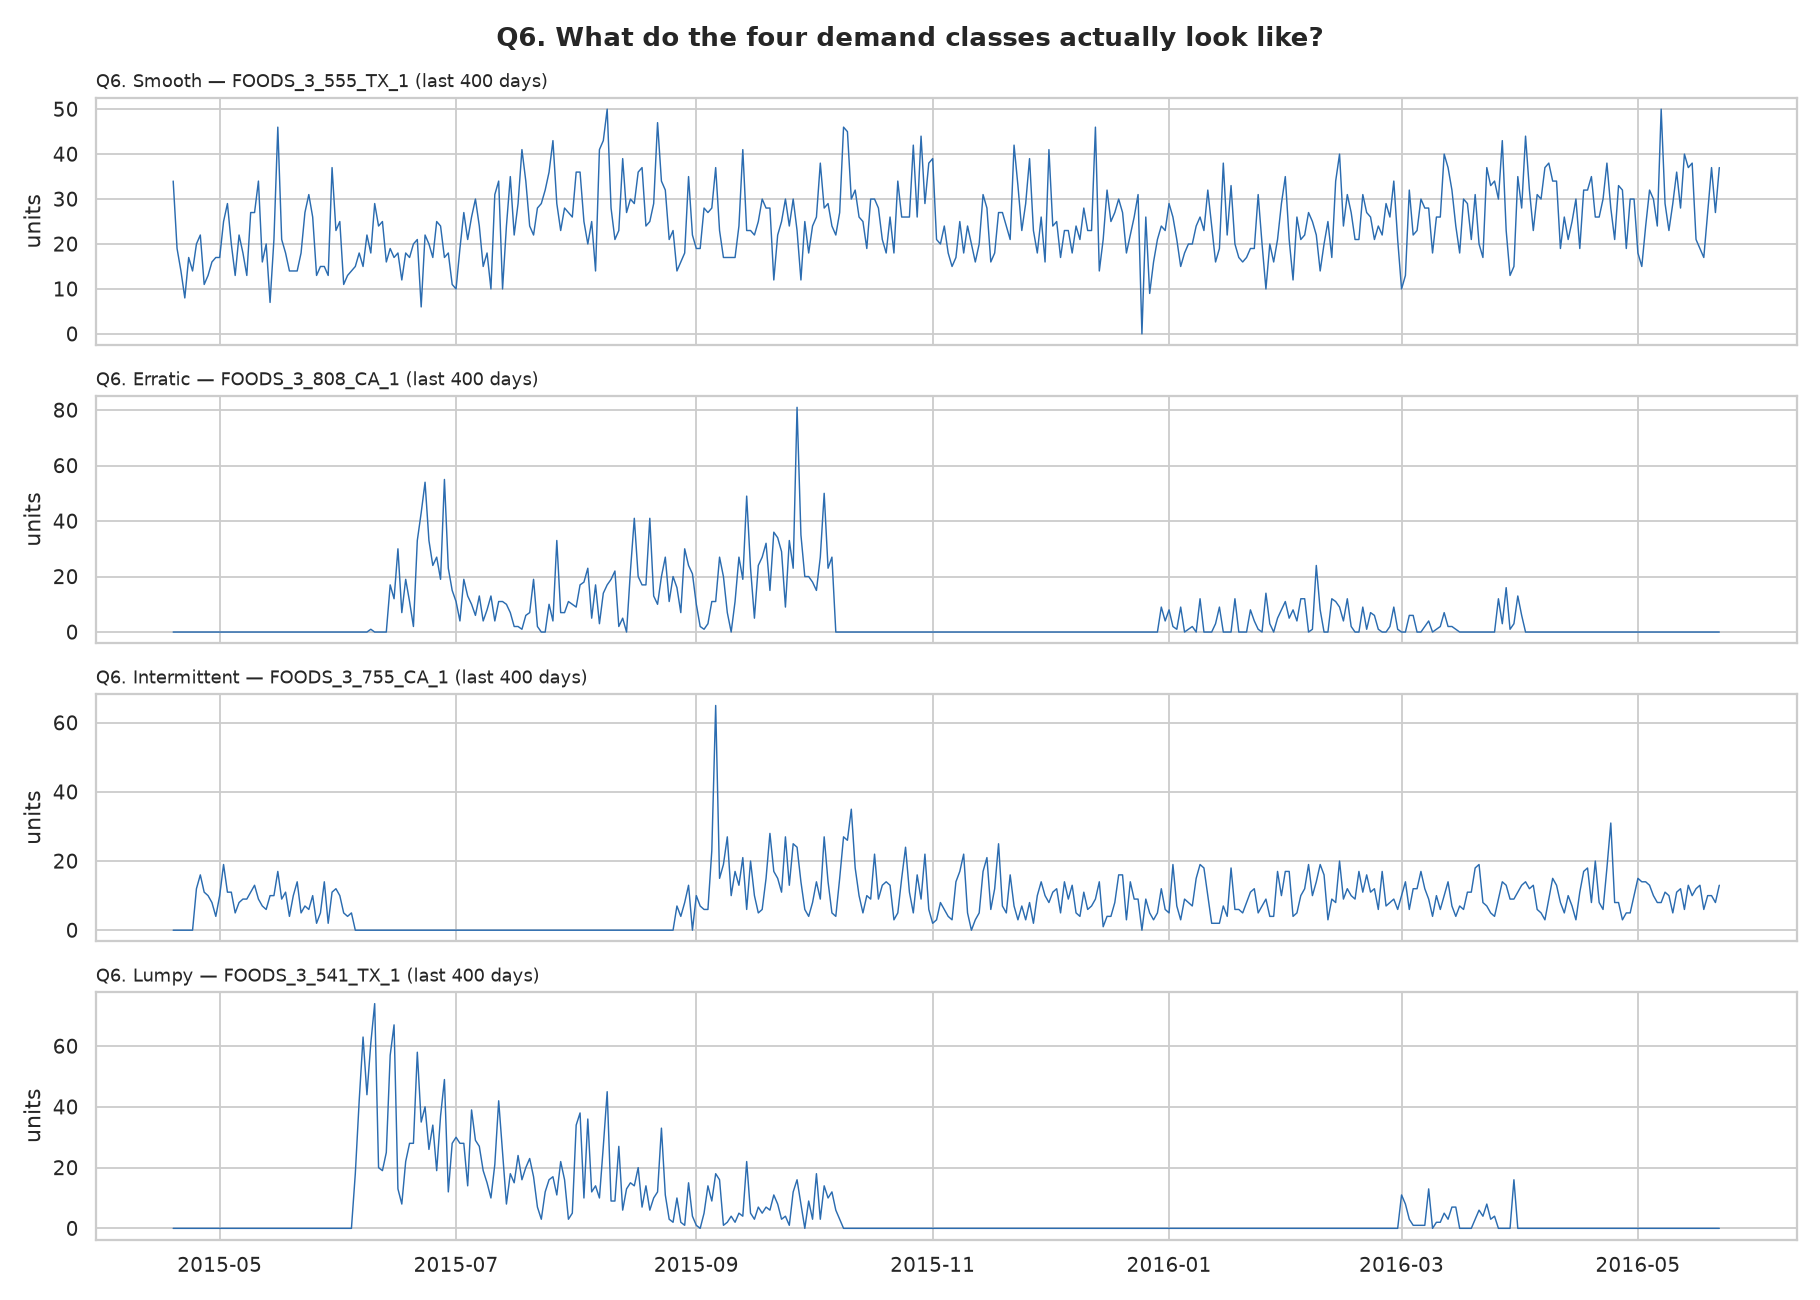

In [3]:
from IPython.display import Image, display
figdir = cfg.resolve('paths','figures_dir')
for f in ('01_demand_trend','02_seasonality','03_demand_concentration',
          '04_intermittency','05_price_and_volatility','06_demand_classes'):
    display(Image(str(figdir / f'{f}.png')))

## What the numbers say

In [4]:
{k: v for k, v in findings.items() if not isinstance(v, dict)}

{'n_rows': 986800,
 'n_series': 600,
 'n_days': 1941,
 'date_min': '2011-01-29',
 'date_max': '2016-05-22',
 'zero_share': 0.5895156059991893,
 'mean_demand': 1.6194427013397217,
 'weekly_growth_first_to_last_8w': 0.38141608238220215,
 'dow_ratio_max_min': 1.4985573291778564,
 'dow_peak': 'Sun',
 'snap_lift_pct': 10.217070579528809,
 'share_of_demand_from_top20pct_series': 0.7340535521507263,
 'median_selling_day_share': 0.3768480585856246}

Demand is highly concentrated and highly intermittent at the same time: a small minority of series carry most of the volume, while the median SKU sells on a minority of days. Those two facts pull forecasting in opposite directions and are why the project evaluates per segment.